# Notebook 1 — Analise Exploratoria e Pre-processamento
## Wine Quality Dataset
**Disciplinas:** Matematica para Computacao | IA e suas Aplicacoes | Fundamentos de Programacao | Fundamentos de Logica

Este notebook cobre as etapas de analise exploratoria dos dados (EDA) e pre-processamento
(curadoria) do Wine Quality Dataset, preparando os dados para uso no algoritmo KNN.

---

## 1. Importacao das Bibliotecas

Bibliotecas utilizadas exclusivamente para analise e visualizacao dos dados.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100
print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 2. Carregamento do Dataset

O **Wine Quality Dataset** contem informacoes fisico-quimicas de vinhos tintos e brancos
da regiao do Minho (Portugal), avaliados por especialistas. E amplamente usado como
benchmark em tarefas de classificacao.

**Fonte:** UCI Machine Learning Repository — P. Cortez, A. Cerdeira, F. Almeida, T. Matos e J. Reis (2009)

**Atributos:**
- `fixed acidity`, `volatile acidity`, `citric acid`: acidez do vinho
- `residual sugar`: acucar residual apos fermentacao
- `chlorides`: concentracao de cloreto de sodio
- `free sulfur dioxide`, `total sulfur dioxide`: dioxido de enxofre (conservante)
- `density`: densidade do liquido
- `pH`: nivel de acidez geral
- `sulphates`: sulfato de potassio (antimicrobiano e antioxidante)
- `alcohol`: teor alcoolico (% por volume)
- `quality`: nota de qualidade de 0 a 10 (variavel alvo)
- `type`: tipo do vinho (red / white)

In [3]:
# Carrega o arquivo CSV bruto
df = pd.read_csv("wine_quality_dataset.csv")

print(f"Dimensoes do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"\nNomes das colunas:")
for col in df.columns:
    print(f"  - {col}")
df.head(10)

Dimensoes do dataset: 6497 linhas x 13 colunas

Nomes das colunas:
  - fixed acidity
  - volatile acidity
  - citric acid
  - residual sugar
  - chlorides
  - free sulfur dioxide
  - total sulfur dioxide
  - density
  - pH
  - sulphates
  - alcohol
  - quality
  - type


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,red
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,red
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,red
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,red
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,red


## 3. Analise Exploratoria dos Dados (EDA)

### 3.1 Estatisticas Descritivas

As estatisticas descritivas revelam a escala e distribuicao de cada atributo.
Percebe-se que as variaveis estao em escalas muito diferentes (ex.: `total sulfur dioxide`
pode passar de 200, enquanto `chlorides` fica abaixo de 1), o que justifica a normalizacao.

In [4]:
# Estatisticas descritivas completas
print("=== Estatisticas Descritivas ===")
df.describe().round(3)

=== Estatisticas Descritivas ===


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000
mean,7.215,0.340,0.319,5.443,0.056,30.525,115.745,0.995,3.219,0.531,10.492,5.818
std,1.296,0.165,0.145,4.758,0.035,17.749,56.522,0.003,0.161,0.149,1.193,0.873
min,3.800,0.080,0.000,0.600,0.009,1.000,6.000,0.987,2.720,0.220,8.000,3.000
25%,6.400,0.230,0.250,1.800,0.038,17.000,77.000,0.992,3.110,0.430,9.500,5.000
50%,7.000,0.290,0.310,3.000,0.047,29.000,118.000,0.995,3.210,0.510,10.300,6.000
75%,7.700,0.400,0.390,8.100,0.065,41.000,156.000,0.997,3.320,0.600,11.300,6.000
max,15.900,1.580,1.660,65.800,0.611,289.000,440.000,1.039,4.010,2.000,14.900,9.000


### 3.2 Verificacao de Valores Ausentes

Valores ausentes podem distorcer o calculo de distancias no KNN. Verificamos aqui se existe a necessidade de tratamento.

In [5]:
# Verificar valores ausentes em cada coluna
print("=== Valores Ausentes por Coluna ===")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("Nenhum valor ausente encontrado! O dataset esta completo.")
else:
    print(missing[missing > 0])
    print(f"\nTotal de celulas ausentes: {missing.sum()}")

=== Valores Ausentes por Coluna ===
Nenhum valor ausente encontrado! O dataset esta completo.


### 3.3 Tipos de Dados

Verificamos os tipos de cada coluna para identificar o que precisa ser tratado no pre-processamento.

In [6]:
# Tipos de dados e contagens
print("=== Tipos de Dados ===")
print(df.dtypes)
print(f"\nValores unicos na coluna 'type': {df['type'].unique()}")
print(f"Quantidade por tipo:\n{df['type'].value_counts()}")

=== Tipos de Dados ===
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
type                        str
dtype: object

Valores unicos na coluna 'type': <StringArray>
['red', 'white']
Length: 2, dtype: str
Quantidade por tipo:
type
white    4898
red      1599
Name: count, dtype: int64


### 3.4 Distribuicao da Variavel Alvo

A variavel `quality` e a que queremos classificar. E fundamental entender sua distribuicao
para antecipar o desafio do **desbalanceamento de classes** — situacao em que algumas classes
teem muito mais amostras que outras, o que pode influenciar negativamente o modelo.

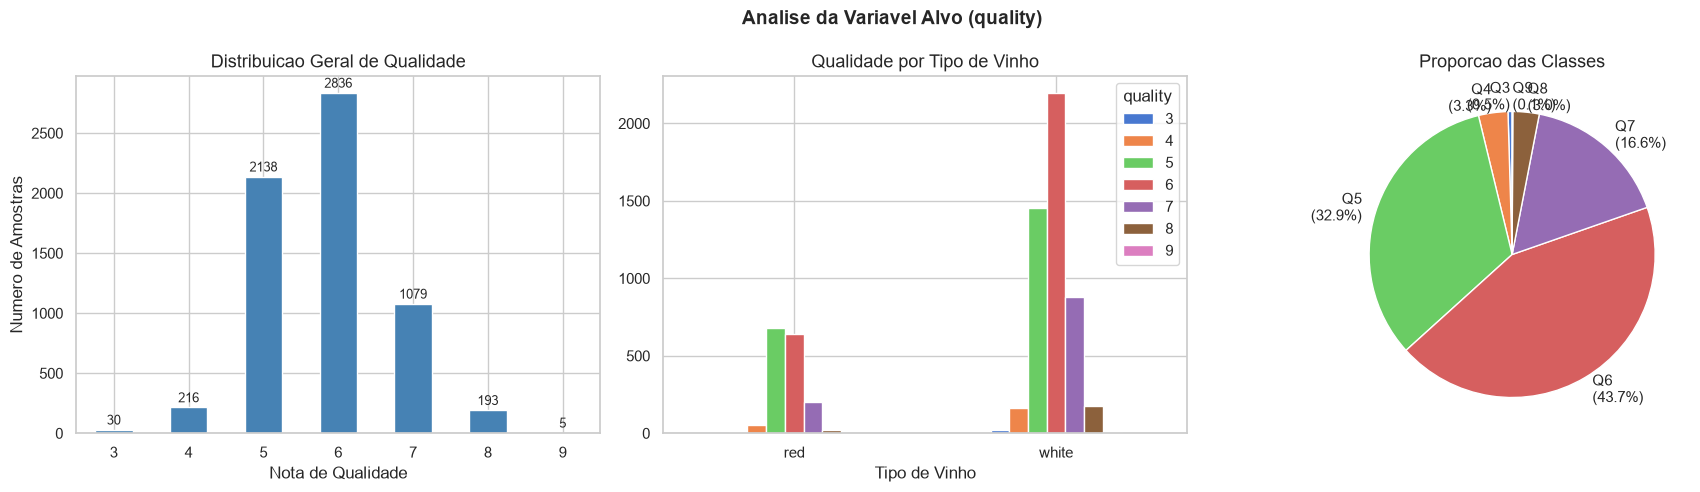


Classes dominantes: nota 5 (2138 amostras) e nota 6 (2836 amostras)
Percentual combinado: 76.6% do total
ATENCAO: dataset desbalanceado - classes 5 e 6 dominam com mais de 75% das amostras!


In [7]:
# Graficos de distribuicao da variavel alvo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Grafico 1: distribuicao geral
contagem = df['quality'].value_counts().sort_index()
contagem.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Distribuicao Geral de Qualidade', fontsize=13)
axes[0].set_xlabel('Nota de Qualidade')
axes[0].set_ylabel('Numero de Amostras')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(int(bar.get_height())), ha='center', va='bottom', fontsize=9)

# Grafico 2: distribuicao por tipo
df.groupby(['type', 'quality']).size().unstack().plot(
    kind='bar', ax=axes[1], edgecolor='white')
axes[1].set_title('Qualidade por Tipo de Vinho', fontsize=13)
axes[1].set_xlabel('Tipo de Vinho')
axes[1].tick_params(axis='x', rotation=0)

# Grafico 3: pie chart das classes
pct = contagem / contagem.sum() * 100
axes[2].pie(pct, labels=[f"Q{i}\n({v:.1f}%)" for i, v in zip(pct.index, pct)],
            startangle=90, colors=sns.color_palette("muted", len(pct)))
axes[2].set_title('Proporcao das Classes', fontsize=13)

plt.suptitle('Analise da Variavel Alvo (quality)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_distribuicao_qualidade.png", bbox_inches='tight')
plt.show()

print(f"\nClasses dominantes: nota 5 ({contagem[5]} amostras) e nota 6 ({contagem[6]} amostras)")
print(f"Percentual combinado: {(contagem[5]+contagem[6])/len(df)*100:.1f}% do total")
print("ATENCAO: dataset desbalanceado - classes 5 e 6 dominam com mais de 75% das amostras!")

### 3.5 Matriz de Correlacao

A correlacao de Pearson mede a relacao linear entre pares de variaveis (-1 a +1).
Identificar quais atributos se correlacionam com `quality` orienta a selecao de features.

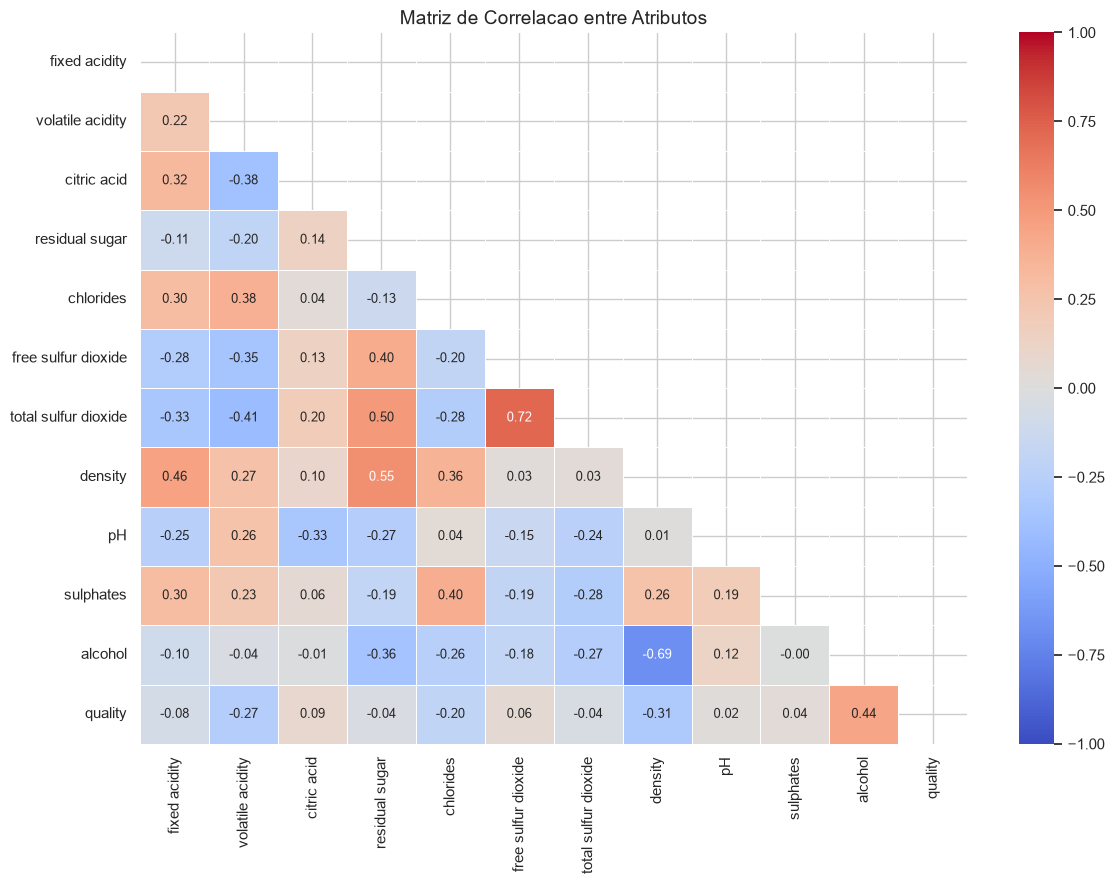

=== Correlacao de cada atributo com 'quality' ===
  alcohol                       : +0.444 (positiva)
  citric acid                   : +0.086 (positiva)
  free sulfur dioxide           : +0.055 (positiva)
  sulphates                     : +0.038 (positiva)
  pH                            : +0.020 (positiva)
  residual sugar                : -0.037 (negativa)
  total sulfur dioxide          : -0.041 (negativa)
  fixed acidity                 : -0.077 (negativa)
  chlorides                     : -0.201 (negativa)
  volatile acidity              : -0.266 (negativa)
  density                       : -0.306 (negativa)


In [8]:
# Heatmap de correlacao
fig, ax = plt.subplots(figsize=(12, 9))
corr = df.drop(columns=['type']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # mostra apenas triangulo inferior
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            ax=ax, linewidths=0.5, vmin=-1, vmax=1, annot_kws={"size": 9})
ax.set_title("Matriz de Correlacao entre Atributos", fontsize=14)
plt.tight_layout()
plt.savefig("eda_correlacao.png", bbox_inches='tight')
plt.show()

# Correlacoes com a variavel alvo
print("=== Correlacao de cada atributo com 'quality' ===")
corr_quality = corr['quality'].drop('quality').sort_values(ascending=False)
for feat, val in corr_quality.items():
    direcao = "positiva" if val > 0 else "negativa"
    print(f"  {feat:30s}: {val:+.3f} ({direcao})")

### 3.6 Boxplots dos Atributos por Classe de Qualidade

Os boxplots mostram como cada atributo se distribui dentro de cada nota de qualidade.
Atributos com grande variacao entre classes sao melhores preditores para o KNN.

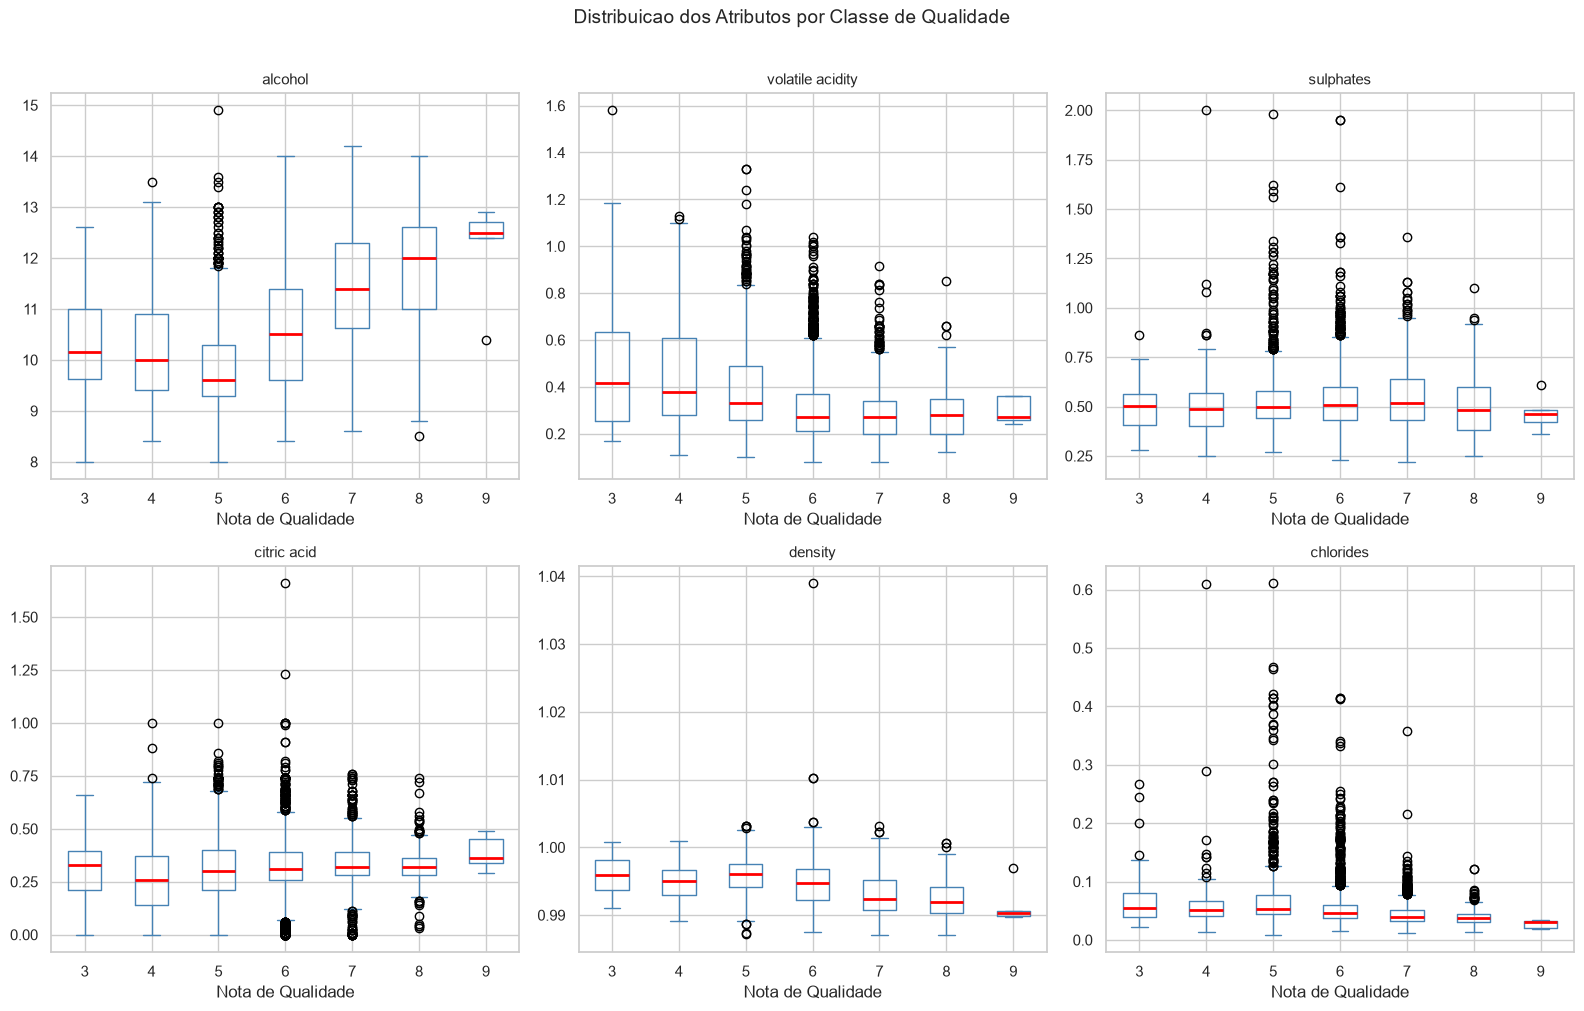

In [9]:
# Boxplots dos 6 atributos mais correlacionados com quality
features_plot = ['alcohol', 'volatile acidity', 'sulphates',
                 'citric acid', 'density', 'chlorides']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(features_plot):
    df.boxplot(column=feat, by='quality', ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', linewidth=2),
               whiskerprops=dict(color='steelblue'),
               capprops=dict(color='steelblue'))
    axes[i].set_title(feat, fontsize=11)
    axes[i].set_xlabel('Nota de Qualidade')
    plt.setp(axes[i].get_xticklabels(), rotation=0)

plt.suptitle('Distribuicao dos Atributos por Classe de Qualidade', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("eda_boxplots.png", bbox_inches='tight')
plt.show()

### 3.7 Distribuicao dos Atributos (Histogramas)

Histogramas revelam a forma da distribuicao de cada variavel — se e normal, assimetrica, com outliers, etc.

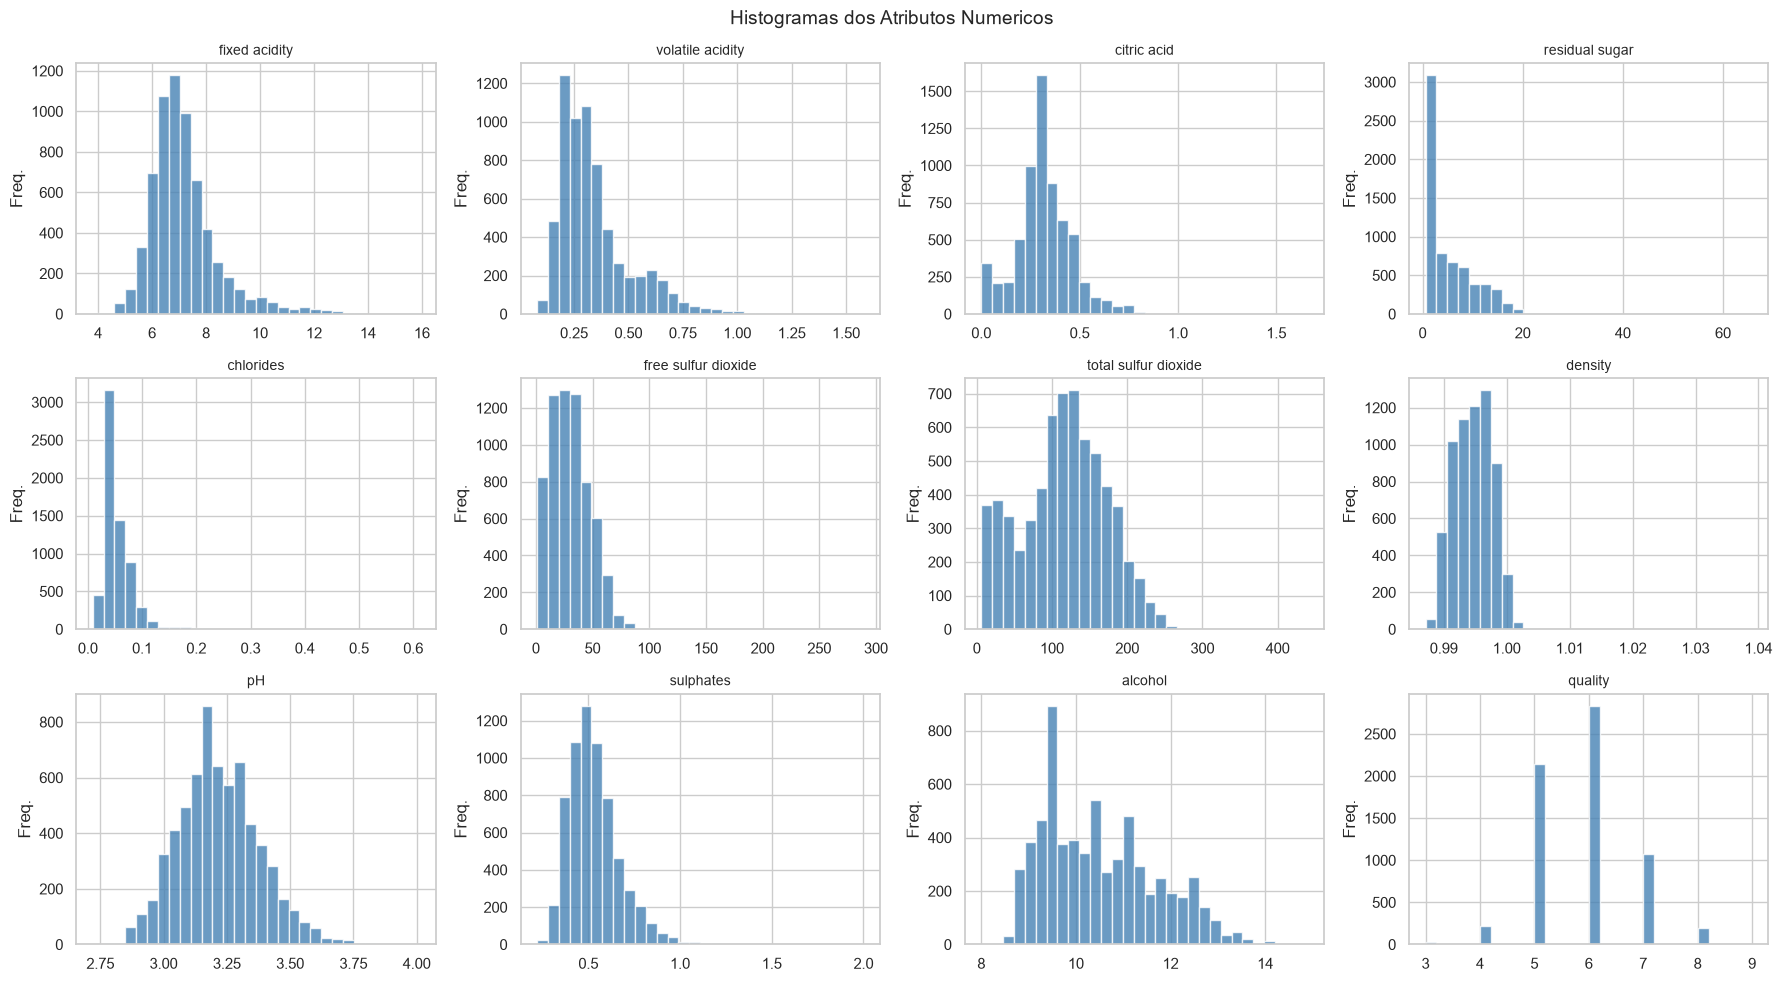

In [10]:
# Histogramas de todos os atributos numericos
features_num = df.select_dtypes(include=[np.number]).columns.tolist()
n_cols = 4
n_rows = (len(features_num) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(features_num):
    axes[i].hist(df[feat], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(feat, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Freq.')

# Oculta eixos extras
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histogramas dos Atributos Numericos', fontsize=14)
plt.tight_layout()
plt.savefig("eda_histogramas.png", bbox_inches='tight')
plt.show()

## 4. Pre-processamento (Curadoria dos Dados)

Com base na analise exploratoria, tomamos as seguintes decisoes de pre-processamento:

| Passo | Decisao | Justificativa |
|-------|---------|---------------|
| 1 | Remover coluna `type` | Texto categorico; o KNN trabalha com distancias numericas |
| 2 | Binarizar `quality` | Simplifica para classificacao binaria: boa (>=7) vs ruim (<7) |
| 3 | Normalizar com Z-score | Atributos em escalas muito diferentes distorceriam a distancia Euclidiana |
| 4 | Divisao 80/20 treino/teste | Padrao amplamente utilizado; seed fixo garante reproducibilidade |


In [11]:
# Passo 1: copiar e remover coluna categorica 'type'
# A coluna 'type' contem texto (red/white). O KNN usa distancia Euclidiana
# entre valores numericos, portanto ela nao pode ser usada diretamente.
df_prep = df.drop(columns=['type']).copy()
print(f"Colunas apos remocao de 'type': {list(df_prep.columns)}")

Colunas apos remocao de 'type': ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [12]:
# Passo 2: binarizar a variavel alvo
# Convertemos as notas de 3-9 em duas categorias:
#   - Boa (1): quality >= 7  -> vinhos de alta qualidade
#   - Ruim (0): quality < 7  -> vinhos de qualidade mediana ou baixa
# Essa escolha foi feita porque notas >= 7 sao classicamente consideradas
# 'bons vinhos' na literatura e facilitam a interpretacao dos resultados.
df_prep['qualidade_binaria'] = (df_prep['quality'] >= 7).astype(int)
df_prep = df_prep.drop(columns=['quality'])

print("=== Distribuicao das classes binarias ===")
cnt = df_prep['qualidade_binaria'].value_counts()
print(f"  Ruim (0 - quality < 7):  {cnt[0]} amostras ({cnt[0]/len(df_prep)*100:.1f}%)")
print(f"  Boa  (1 - quality >= 7): {cnt[1]} amostras ({cnt[1]/len(df_prep)*100:.1f}%)")
df_prep.head()

=== Distribuicao das classes binarias ===
  Ruim (0 - quality < 7):  5220 amostras (80.3%)
  Boa  (1 - quality >= 7): 1277 amostras (19.7%)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,qualidade_binaria
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


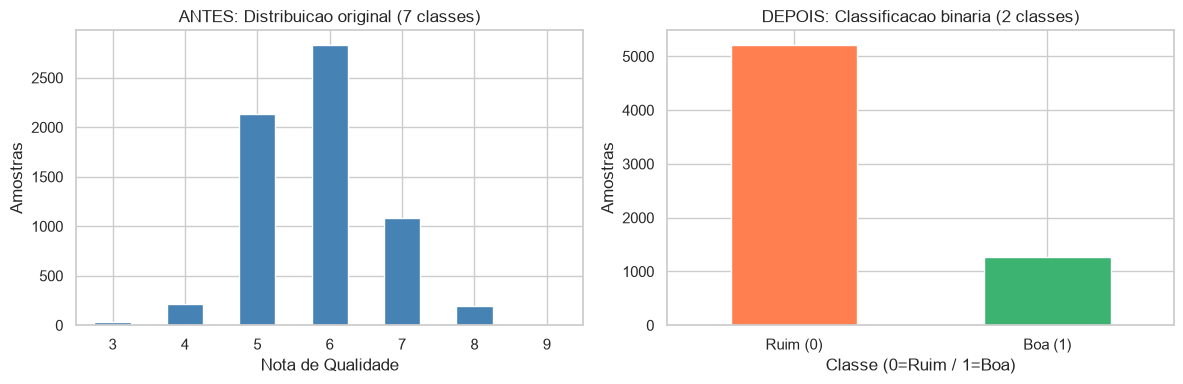

In [13]:
# Visualizacao: distribuicao antes e depois da binarizacao
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Antes
df['quality'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('ANTES: Distribuicao original (7 classes)', fontsize=12)
axes[0].set_xlabel('Nota de Qualidade')
axes[0].set_ylabel('Amostras')
axes[0].tick_params(axis='x', rotation=0)

# Depois
df_prep['qualidade_binaria'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color=['coral', 'mediumseagreen'], edgecolor='white')
axes[1].set_title('DEPOIS: Classificacao binaria (2 classes)', fontsize=12)
axes[1].set_xlabel('Classe (0=Ruim / 1=Boa)')
axes[1].set_ylabel('Amostras')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_xticklabels(['Ruim (0)', 'Boa (1)'])

plt.tight_layout()
plt.savefig("prep_binarizacao.png", bbox_inches='tight')
plt.show()

In [14]:
# Passo 3: separar features (X) e variavel alvo (y)
X = df_prep.drop(columns=['qualidade_binaria']).values
y = df_prep['qualidade_binaria'].values
feature_names = list(df_prep.drop(columns=['qualidade_binaria']).columns)

print(f"Features ({len(feature_names)}): {feature_names}")
print(f"Shape X: {X.shape} | Shape y: {y.shape}")

Features (11): ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Shape X: (6497, 11) | Shape y: (6497,)


In [15]:
# Passo 4: divisao treino (80%) e teste (20%) com seed fixo
np.random.seed(42)
indices = np.random.permutation(len(X))
split   = int(0.8 * len(X))

X_train_raw, X_test_raw = X[indices[:split]], X[indices[split:]]
y_train,      y_test     = y[indices[:split]], y[indices[split:]]

print(f"Total: {len(X)} | Treino: {len(X_train_raw)} ({len(X_train_raw)/len(X)*100:.0f}%) | Teste: {len(X_test_raw)} ({len(X_test_raw)/len(X)*100:.0f}%)")

Total: 6497 | Treino: 5197 (80%) | Teste: 1300 (20%)


In [16]:
# Passo 5: normalizacao Z-score calculada apenas com dados de treino
# Formula: x_normalizado = (x - media_treino) / desvio_treino
# IMPORTANTE: usamos os parametros do treino para transformar TAMBEM o teste.
# Isso evita data leakage (o modelo nunca "ve" informacoes do teste durante o treino).
media_treino  = X_train_raw.mean(axis=0)
desvio_treino = X_train_raw.std(axis=0)

X_train_norm = (X_train_raw - media_treino) / desvio_treino
X_test_norm  = (X_test_raw  - media_treino) / desvio_treino

print("=== Verificacao da normalizacao no conjunto de treino ===")
print(f"{'Feature':<28} {'Media antes':>14} {'Media depois':>14} {'Desvio depois':>14}")
print("-" * 72)
for i, feat in enumerate(feature_names):
    print(f"{feat:<28} {X_train_raw[:,i].mean():>14.4f} {X_train_norm[:,i].mean():>14.4f} {X_train_norm[:,i].std():>14.4f}")

=== Verificacao da normalizacao no conjunto de treino ===
Feature                         Media antes   Media depois  Desvio depois
------------------------------------------------------------------------
fixed acidity                        7.2230        -0.0000         1.0000
volatile acidity                     0.3410        -0.0000         1.0000
citric acid                          0.3183         0.0000         1.0000
residual sugar                       5.4545        -0.0000         1.0000
chlorides                            0.0566        -0.0000         1.0000
free sulfur dioxide                 30.4202        -0.0000         1.0000
total sulfur dioxide               115.4394         0.0000         1.0000
density                              0.9947         0.0000         1.0000
pH                                   3.2184         0.0000         1.0000
sulphates                            0.5334        -0.0000         1.0000
alcohol                             10.4866        -0.0

In [17]:
# Salvar os dados preparados (filtrados) em CSV — item 4 do Entregavel 2
df_filtrado = pd.DataFrame(
    np.hstack([X, y.reshape(-1,1)]),
    columns=feature_names + ['qualidade_binaria']
)
df_filtrado.to_csv("wine_quality_filtrado.csv", index=False)

print("Arquivo 'wine_quality_filtrado.csv' salvo com sucesso!")
print(f"Shape: {df_filtrado.shape}")
print(f"\nPrimeiras 5 linhas:")
df_filtrado.head()

Arquivo 'wine_quality_filtrado.csv' salvo com sucesso!
Shape: (6497, 12)

Primeiras 5 linhas:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,qualidade_binaria
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0.0


In [18]:
# Salvar tambem os parametros de normalizacao para uso no Notebook 2
params = pd.DataFrame({
    'feature': feature_names,
    'media': media_treino,
    'desvio': desvio_treino
})
params.to_csv("normalizacao_params.csv", index=False)

print("Parametros de normalizacao salvos em 'normalizacao_params.csv'")
print(params.to_string(index=False))

Parametros de normalizacao salvos em 'normalizacao_params.csv'
             feature      media    desvio
       fixed acidity   7.222975  1.310174
    volatile acidity   0.340963  0.164295
         citric acid   0.318305  0.144402
      residual sugar   5.454474  4.713679
           chlorides   0.056574  0.036740
 free sulfur dioxide  30.420242 17.888238
total sulfur dioxide 115.439388 57.023997
             density   0.994726  0.002962
                  pH   3.218439  0.161578
           sulphates   0.533383  0.151347
             alcohol  10.486601  1.192115


In [19]:
# Salvar indices de treino e teste para reproducibilidade
np.save("indices_treino.npy", indices[:split])
np.save("indices_teste.npy", indices[split:])

print("Indices de divisao treino/teste salvos!")
print(f"Indices treino: {len(indices[:split])} | Indices teste: {len(indices[split:])}")

Indices de divisao treino/teste salvos!
Indices treino: 5197 | Indices teste: 1300


## 5. Resumo do Pre-processamento

| Etapa | Antes | Depois |
|-------|-------|--------|
| Linhas | 6497 | 6497 |
| Colunas | 13 | 11 |
| Coluna removida | `type` (texto) | — |
| Variavel alvo | `quality` (3 a 9, 7 classes) | `qualidade_binaria` (0 ou 1) |
| Normalizacao | Nao | Sim (Z-score) |
| Conjunto de treino | — | 5197 amostras (80%) |
| Conjunto de teste | — | 1300 amostras (20%) |

**Arquivos gerados por este notebook:**
- `wine_quality_filtrado.csv` — dados preparados (sem coluna type, com qualidade binaria)
- `normalizacao_params.csv` — media e desvio padrao de cada feature (calculados no treino)
- `indices_treino.npy` / `indices_teste.npy` — indices da divisao treino/teste
